In [19]:
from lowresource_llm_evaluation.exploreResults import pretty_print_results, load_results
from lowresource_llm_evaluation.exploreResults import generate_latex_snippet_compacto, generate_html_report, merge_latex_files
from lowresource_llm_evaluation.exploreResults import generar_grafico_barras, explorar_estructuras

raw_base = "./results/Raw/"
raw_lora = "./results_lora/Raw/"
salida_base = "./results/Processed/"
salida_lora = "./results_lora/Processed/"
figures_base = "./results/Figures/"
figures_lora = "./results_lora/Figures/"

idiomas = [ "asturiano", "aranes", "gallego"]

In [20]:
pretty_print_results(load_results(raw_base + "aranes/resultados_aranes_Mistral-7B-Instruct-v0.3_05-10_20-28-27.json"))


      RESULTADOS DEL MODELO



########################################
### TAREA: CALIDAD_LENGUA
########################################

▶ MÉTRICAS GLOBALES

Métrica          Valor
---------------  -----------------------------------------------------
ttr              0.4681802796379446
entropy          6.8886785153068555
ngram_overlap    0.0
freq_target      0.4698188801536519
freq_comparison  {'es': 0.4670386513003484, 'fr': 0.30053548526423357}
calidad          0.17817821296635833


▶ EJEMPLOS


--- Ejemplo 1 ---
text: En els primers temps de la seva existència, l'Aragon era una terra desolada i salvatge, habitada per uns primitius homes nòmades, coneguts com els Aragonesos. Aquestos gentils home...
ttr: 0.47306791569086654
entropy: 6.908985512841516
ngram_overlap: 0.0
freq_target: 0.48009367681498827
freq_comparison: {'es': 0.47540983606557374, 'fr': 0.3255269320843091}
calidad: 0.18066158847216107
---------------------------


########################################
### TAREA

### Resultados modelos base

In [21]:

resultados_base = {
"aranes":{
    "Gemma 7B": load_results(raw_base + "aranes/resultados_aranes_gemma-7b-it_05-10_22-05-37.json"),
    "Mistral 7B": load_results(raw_base + "aranes/resultados_aranes_Mistral-7B-Instruct-v0.3_05-10_20-28-27.json"),
    "Qwen2.5 7B": load_results(raw_base + "aranes/resultados_aranes_Qwen2.5-7B-Instruct_05-10_22-57-01.json"),
    "Salamandra 7B": load_results(raw_base + "aranes/resultados_aranes_salamandra-7b-instruct_05-10_20-50-02.json"),
}, 
"asturiano": {
    "Gemma 7B": load_results(raw_base + "asturiano/resultados_asturiano_gemma-7b-it_05-11_07-54-56.json"),
    "Mistral 7B": load_results(raw_base + "asturiano/resultados_asturiano_Mistral-7B-Instruct-v0.3_05-10_23-51-44.json"),
    "Qwen2.5 7B": load_results(raw_base + "asturiano/resultados_asturiano_Qwen2.5-7B-Instruct_05-11_08-41-23.json"),
    "Salamandra 7B": load_results(raw_base + "asturiano/resultados_asturiano_salamandra-7b-instruct_05-11_00-53-38.json"),
},
"gallego":{
    "Gemma 7B": load_results(raw_base + "gallego/resultados_gallego_gemma-7b-it_05-11_12-04-22.json"),
    "Mistral 7B": load_results(raw_base + "gallego/resultados_gallego_Mistral-7B-Instruct-v0.3_05-11_09-34-03.json"),
    "Qwen2.5 7B": load_results(raw_base + "gallego/resultados_gallego_Qwen2.5-7B-Instruct_05-11_20-17-43.json"),
    "Salamandra 7B": load_results(raw_base + "gallego/resultados_gallego_salamandra-7b-instruct_05-11_10-48-06.json"),
}
}

In [22]:
generate_html_report(resultados_base["aranes"], salida_base + "aranes_resultados_base.html")

generate_html_report(resultados_base["asturiano"], salida_base + "asturiano_resultados_base.html")

generate_html_report(resultados_base["gallego"], salida_base + "gallego_resultados_base.html")

HTML generado en: ./results/Processed/aranes_resultados_base.html
HTML generado en: ./results/Processed/asturiano_resultados_base.html
HTML generado en: ./results/Processed/gallego_resultados_base.html


In [23]:


generate_latex_snippet_compacto(resultados_base["aranes"], lengua="Aranés", output_path= salida_base + "aranes_resultados_base.tex")

generate_latex_snippet_compacto(resultados_base["asturiano"], lengua="Asturiano", output_path= salida_base + "asturiano_resultados_base.tex")

generate_latex_snippet_compacto(resultados_base["gallego"], lengua="Gallego", output_path= salida_base + "gallego_resultados_base.tex")
merge_latex_files([salida_base + lang + "_resultados_base.tex" for lang in idiomas], 
                  salida_base + "resultados_base.tex", "Resultados de los modelos base")

Éxito: Archivo consolidado creado en ./results/Processed/resultados_base.tex


## Resultados QLoRA

In [24]:

resultados_qlora = {
    "asturiano":{
    "Base": load_results(raw_base + "asturiano/resultados_asturiano_Qwen2.5-7B-Instruct_05-11_08-41-23.json"),
    "Entrenado": load_results(raw_lora + "asturiano/resultados_QLORA_asturiano_modelo3200SinConcatenar_05-21_21-02-27.json"),
    "Concatenado": load_results(raw_lora + "asturiano/resultados_QLORA_asturiano_37500-asturiano-concatenado_05-21_20-00-48.json"),
    "Concatenado + Inst": load_results(raw_lora + "asturiano/resultados_QLORA_asturiano_39000-asturiano-concatenado-Instructivo_05-21_20-36-47.json"),
},
"aranes":{
    "Base": load_results(raw_base + "aranes/resultados_aranes_Qwen2.5-7B-Instruct_05-10_22-57-01.json"),
    "Entrenado": load_results(raw_lora + "aranes/resultados_QLORA_aranes_31000.json"),
    "Entrenado + Inst": load_results(raw_lora + "aranes/resultados_QLORA_aranes_31000+2000_Instructivo.json"),
    },
"gallego":{
    "Base": load_results(raw_base + "gallego/resultados_gallego_Qwen2.5-7B-Instruct_05-11_20-17-43.json"),
    "Entrenado": load_results(raw_lora + "gallego/resultados_QLORA_gallego_checkpoint-30000_05-27_16-48-36.json"),
    },
}


In [25]:
generate_html_report({
    "Qwen2.5 7B": load_results(raw_base + "asturiano/resultados_asturiano_Qwen2.5-7B-Instruct_05-11_08-41-23.json"),
    "Concatenated 37500": load_results(raw_lora + "asturiano/resultados_QLORA_asturiano_37500-asturiano-concatenado_05-21_20-00-48.json"),
    "37500 + Instructivo": load_results(raw_lora + "asturiano/resultados_QLORA_asturiano_39000-asturiano-concatenado-Instructivo_05-21_20-36-47.json"),
    "Not Concatenated 32000": load_results(raw_lora + "asturiano/resultados_QLORA_asturiano_modelo3200SinConcatenar_05-21_21-02-27.json"),
    "32000 + Instructivo": load_results(raw_lora + "asturiano/resultados_QLORA_asturiano_modelo3500SinConcatenar-Instructivo_05-21_21-27-42.json"),
}, output_path= salida_lora + "asturiano_resultados_qlora.html")

generate_html_report(resultados_base["aranes"], salida_lora + "aranes_resultados_qlora.html")

generate_html_report(resultados_base["gallego"], salida_lora + "gallego_resultados_qlora.html")

HTML generado en: ./results_lora/Processed/asturiano_resultados_qlora.html
HTML generado en: ./results_lora/Processed/aranes_resultados_qlora.html
HTML generado en: ./results_lora/Processed/gallego_resultados_qlora.html


In [26]:
generate_latex_snippet_compacto(resultados_qlora["asturiano"], lengua="Asturiano QLoRA", output_path= salida_lora + "asturiano_resultados_qlora.tex")
generate_latex_snippet_compacto(resultados_qlora["aranes"], lengua="Aranés QLoRA", output_path= salida_lora + "aranes_resultados_qlora.tex")
generate_latex_snippet_compacto(resultados_qlora["gallego"], lengua="Gallego QLoRA", output_path= salida_lora + "gallego_resultados_qlora.tex")

merge_latex_files([salida_lora + lang + "_resultados_qlora.tex" for lang in idiomas], 
                  salida_lora + "resultados_qlora.tex", "Resultados de los modelos entrenados")

Éxito: Archivo consolidado creado en ./results_lora/Processed/resultados_qlora.tex


In [27]:
explorar_estructuras(load_results(raw_base + "/asturiano/resultados_asturiano_Qwen2.5-7B-Instruct_05-11_08-41-23.json"))

=== MAPA DE TAREAS Y MÉTRICAS DISPONIBLES ===

Tarea: 'calidad_lengua'
    ├── 'ttr'
    ├── 'entropy'
    ├── 'ngram_overlap'
    ├── 'freq_target'
    ├── 'freq_comparison' -> Requiere sub-métrica: ['fr', 'es']
    ├── 'calidad'

Tarea: 'traduccion'
    ├── 'BLEU'
    ├── 'chrF'

Tarea: 'round_trip'
    ├── 'BLEU'
    ├── 'chrF'

Tarea: 'vocabulario'
    ├── 'accuracy'
    ├── 'accuracy_lower'
    ├── 'levenshtein'

Tarea: 'ortografia'
    ├── 'BLEU'
    ├── 'chrF'
    ├── 'Levenshtein'
    ├── 'precision'
    ├── 'recall'
    ├── 'F1'
    ├── 'errores_totales'
    ├── 'errores_corregidos'
    ├── 'errores_no_corregidos'
    ├── 'errores_nuevos'



In [28]:
def calcular_indice_competencia_global(tareas_dict):
    scores = []
    
    # 1. Pilar Traducción: Usamos BLEU (viene en escala 0-100 en tu JSON, ej: 6.65)
    bleu = tareas_dict.get("traduccion", {}).get("media", {}).get("BLEU")
    if isinstance(bleu, (int, float)):
        scores.append(bleu)
        
    # 2. Pilar Ortografía: Usamos F1 (en tu JSON viene como "F1", ej: 0.2301)
    # Como viene en escala 0-1, lo multiplicamos por 100 para unificar escalas
    f1_gramatica = tareas_dict.get("ortografia", {}).get("media", {}).get("F1")
    if isinstance(f1_gramatica, (int, float)):
        if f1_gramatica <= 1.0: 
            f1_gramatica *= 100
        scores.append(f1_gramatica)
        
    # 3. Pilar Vocabulario: Usamos accuracy_lower (en tu JSON viene como "accuracy_lower", ej: 0.0)
    # Si viene en formato 0-1, lo pasamos a base 100
    acc_vocab = tareas_dict.get("vocabulario", {}).get("media", {}).get("accuracy_lower")
    if isinstance(acc_vocab, (int, float)):
        if acc_vocab <= 1.0:
            acc_vocab *= 100
        scores.append(acc_vocab)
        
    # Devolvemos la media de las tres tareas si tenemos datos
    return sum(scores) / len(scores) if scores else None

def calcular_indice_competencia_avanzado(tareas_dict):
    scores = []
    
    # 1. Pilar Traducción: BLEU (0 a 100)
    bleu = tareas_dict.get("traduccion", {}).get("media", {}).get("BLEU")
    if isinstance(bleu, (int, float)):
        scores.append(bleu)
        
    # 2. Pilar Vocabulario: Accuracy Lower (Pasado a base 100)
    acc_vocab = tareas_dict.get("vocabulario", {}).get("media", {}).get("accuracy_lower")
    if isinstance(acc_vocab, (int, float)):
        if acc_vocab <= 1.0:
            acc_vocab *= 100
        scores.append(acc_vocab)
        
    # 3. Nuevo Pilar Ortografía: Índice de No-Degradación (Base 100)
    # Evaluamos cuántos "errores nuevos" mete por cada frase en comparación con una base
    orto_media = tareas_dict.get("ortografia", {}).get("media", {})
    err_nuevos = orto_media.get("errores_nuevos")
    
    if isinstance(err_nuevos, (int, float)):
        # Diseño de la métrica: Empezamos en 100 puntos (perfección). 
        # Restamos una penalización por cada error nuevo que el modelo introduce.
        # Puedes multiplicar 'err_nuevos' por un factor (ej: * 10) si quieres penalizar más duro.
        score_ortografia = max(0, 100 - (err_nuevos * 10)) 
        scores.append(score_ortografia)
    
    return sum(scores) / len(scores) if scores else None

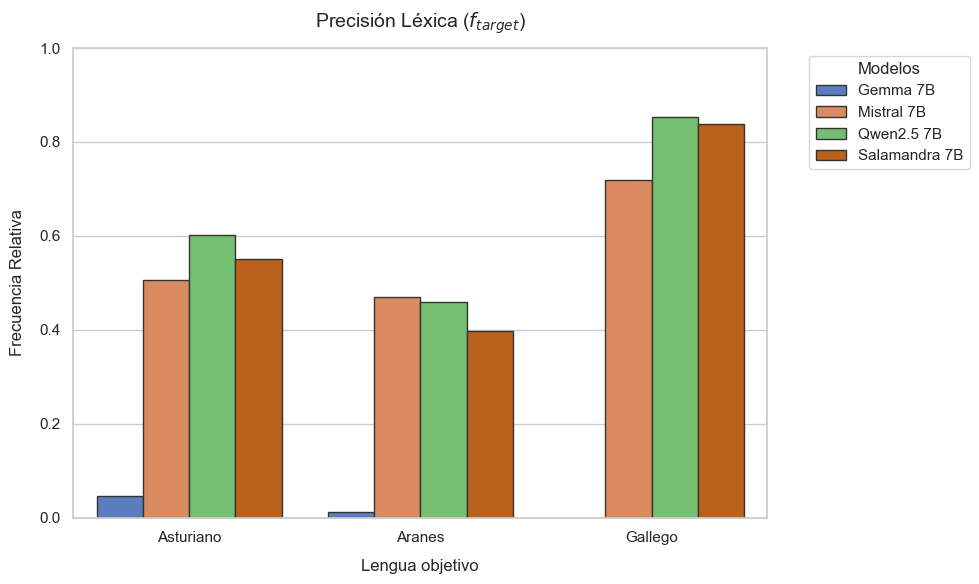

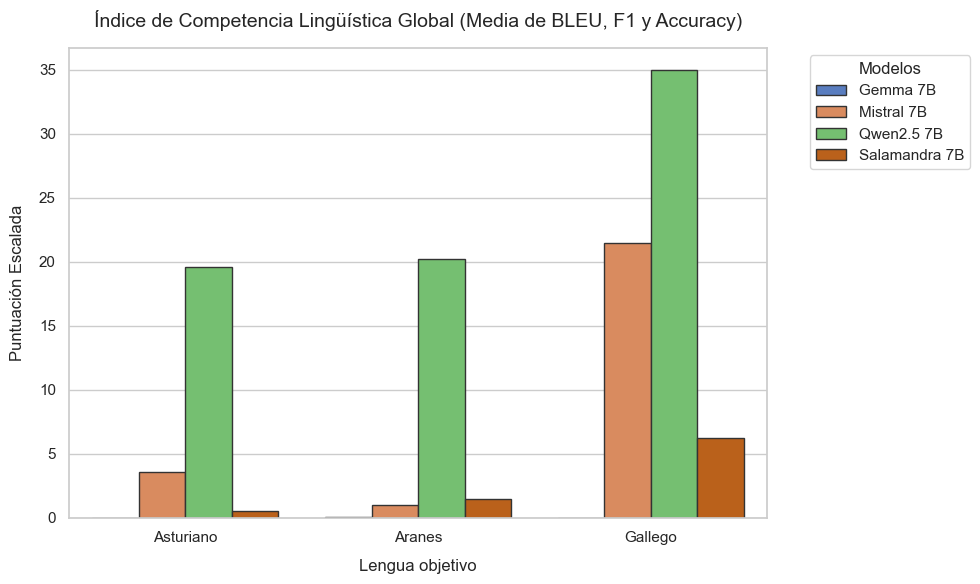

In [29]:
generar_grafico_barras(
    datos_globales=resultados_base,
    extractor="freq_target",
    titulo="Precisión Léxica ($f_{target}$)",
    ylabel="Frecuencia Relativa",
    ylim=(0, 1.0),                 
    idiomas_orden=idiomas,    
    output_path=figures_base + "Calidad_freq_target_base.png",
    motor="sns"
)


generar_grafico_barras(
    datos_globales=resultados_base,
    extractor=calcular_indice_competencia_avanzado,
    titulo="Índice de Competencia Lingüística Global (Media de BLEU, F1 y Accuracy)",
    ylabel="Puntuación Escalada",
    ylim=(0, None),                  
    idiomas_orden=idiomas,     
    output_path=figures_base + "IndiceMetricas_base.png",
    motor="sns"
)

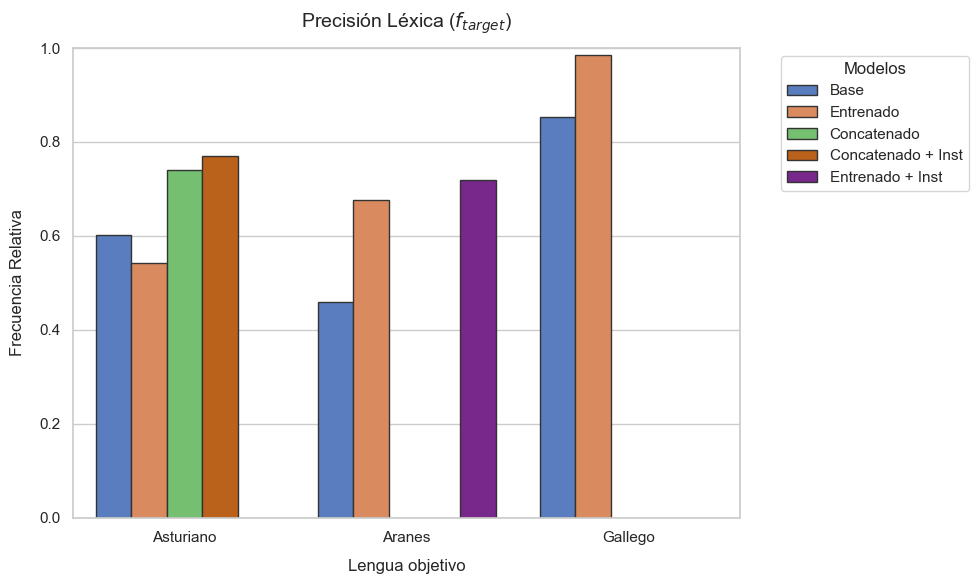

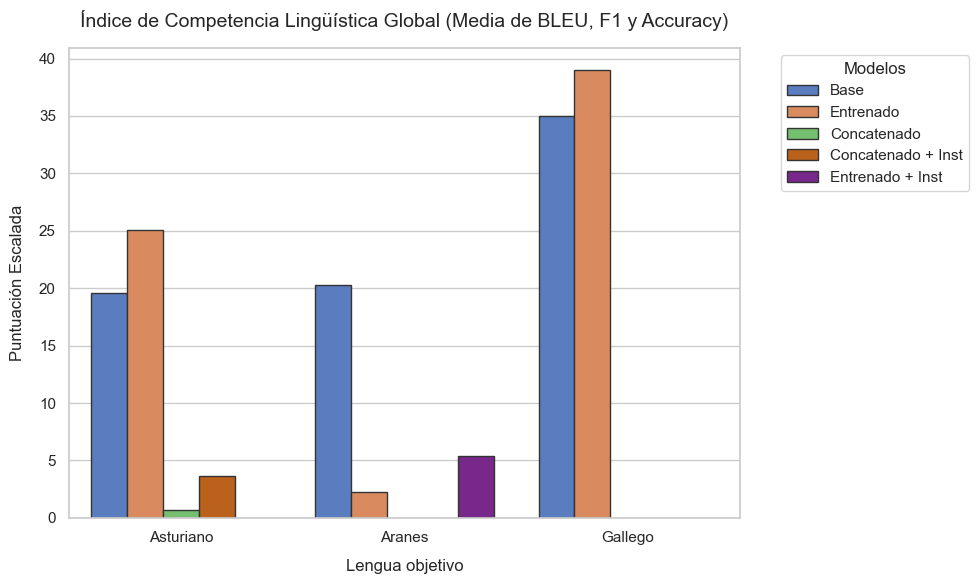

In [30]:
generar_grafico_barras(
    datos_globales=resultados_qlora,
    extractor="freq_target",
    titulo="Precisión Léxica ($f_{target}$)",
    ylabel="Frecuencia Relativa",
    ylim=(0, 1.0),                 
    idiomas_orden=idiomas,    
    output_path= figures_lora + "Calidad_freq_target_qlora.png",
    motor="sns"
)


generar_grafico_barras(
    datos_globales=resultados_qlora,
    extractor=calcular_indice_competencia_avanzado,
    titulo="Índice de Competencia Lingüística Global (Media de BLEU, F1 y Accuracy)",
    ylabel="Puntuación Escalada",
    ylim=(0, None),                  
    idiomas_orden=idiomas,     
    output_path= figures_lora + "IndiceMetricas_qlora.png",
    motor="sns"
)

In [ ]:
# Gráfica 1: Tu métrica nuclear directa
generar_grafico_barras(
    datos_globales=resultados_base,
    extractor="freq_target",
    titulo="Precisión Léxica (f_target)",
    ylabel="Frecuencia Relativa",
    ylim=(0, 1.0),
    idiomas_orden=idiomas,
    output_path= None,
    motor="plotly"
)

# Gráfica 2: El nuevo índice refinado con penalización por errores nuevos
generar_grafico_barras(
    datos_globales=resultados_base,
    extractor=calcular_indice_competencia_avanzado,
    titulo="Índice de Competencia Lingüística Avanzado (Penalizando Degradación Ortográfica)",
    ylabel="Puntuación Escalada (0 - 100)",
    ylim=(0, 100),
    idiomas_orden=idiomas,
    output_path= None,
    motor="plotly"
)

In [ ]:
idiomas = ["asturiano", "aranes", "gallego"]

# Gráfica 1: Tu métrica nuclear directa
generar_grafico_barras(
    datos_globales=resultados_qlora,
    extractor="freq_target",
    titulo="Precisión Léxica (f_target)",
    ylabel="Frecuencia Relativa",
    ylim=(0, 1.0),
    idiomas_orden=idiomas,
    output_path= None,
    motor="plotly"
)

# Gráfica 2: El nuevo índice refinado con penalización por errores nuevos
generar_grafico_barras(
    datos_globales=resultados_qlora,
    extractor=calcular_indice_competencia_avanzado,
    titulo="Índice de Competencia Lingüística Avanzado (Penalizando Degradación Ortográfica)",
    ylabel="Puntuación Escalada (0 - 100)",
    ylim=(0, 100),
    idiomas_orden=idiomas,
    output_path= None,
    motor="plotly"
)